<a href="https://colab.research.google.com/github/ha-thao/31251024728_HaPhuongThao_BTapAIBuoi1/blob/main/faceid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

data_dir = r'/content/drive/MyDrive/60 ẢNH'
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 70
model_path = "/content/drive/MyDrive/face_id_model.keras"

if not os.path.exists(data_dir):
    raise FileNotFoundError(f"The data directory '{data_dir}' does not exist. Please check your Google Drive path.")

print(f"Configuration loaded. Data directory: {data_dir}")

Configuration loaded. Data directory: /content/drive/MyDrive/60 ẢNH


In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = r'/content/drive/MyDrive/60 ẢNH'
IMG_SIZE = 150
BATCH_SIZE = 32

if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Thư mục dữ liệu '{data_dir}' không tồn tại. Vui lòng kiểm tra đường dẫn Google Drive của bạn và đảm bảo nó đã được mount.")
print(f"Sử dụng thư mục dữ liệu: {data_dir}")

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

try:
    train_generator = datagen.flow_from_directory(
        data_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training'
    )

    val_generator = datagen.flow_from_directory(
        data_dir,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation'
    )

    num_classes = train_generator.num_classes
    class_names = list(train_generator.class_indices.keys())

    print(f"\n Tìm thấy {num_classes} lớp (người): {class_names}")
    print(f"Train: {train_generator.samples} ảnh")
    print(f"Val: {val_generator.samples} ảnh")

except Exception as e:
    print(f"Lỗi khi tạo trình tạo dữ liệu: {e}")
    print("Vui lòng đảm bảo đường dẫn 'data_dir' của bạn là chính xác và chứa các thư mục con với hình ảnh cho mỗi lớp.")
    print("Ví dụ: /content/drive/MyDrive/YourFaceDataset/person_A/img1.jpg, /content/drive/MyDrive/YourFaceDataset/person_B/img2.jpg")
    raise


Sử dụng thư mục dữ liệu: /content/drive/MyDrive/60 ẢNH
Found 1544 images belonging to 31 classes.
Found 381 images belonging to 31 classes.

 Tìm thấy 31 lớp (người): ['BUI DANG KHOI', 'DANG NGUYEN PHUONG NGHI', 'HA PHUONG THAO', 'HOANG BAO TRAN', 'HOANG BUI TRA MY', 'LE HUYNH DUC HUY', 'LE MINH TRIET', 'LE THAI BAO', 'LE THI NHU QUYNH', 'LE TRAN QUY ANH', 'LE TRONG DAI', 'MAI HO QUOC TUY', 'NGUYEN BAO HAN', 'NGUYEN DONG HAI', 'NGUYEN HOANG BAO', 'NGUYEN HUU TOAN', 'NGUYEN KHAC LUU VU', 'NGUYEN NGOC KHANH UYEN', 'NGUYEN NGOC KIM TUYET', 'NGUYEN THI THANH HA', 'NGUYEN TRONG MINH', 'NHAN MANH TUAN', 'PHAM DUC THANH CONG', 'PHAM LY BAO LAM', 'PHAM MAI PHUONG', 'THAI TUAN PHAT', 'TRAN GIA HAN', 'TRAN MINH HOANG', 'TRAN NGOC THAO ANH', 'TRAN THE DANG KHOA', 'TRINH THUY HANG']
Train: 1544 ảnh
Val: 381 ảnh


In [4]:
import os
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_path = "/content/drive/MyDrive/face_id_model.keras" # Explicitly set to Drive path

if os.path.exists(model_path):
    print(f"\n Đã tìm thấy mô hình. Tải mô hình cũ để tiếp tục huấn luyện hoặc kiểm tra...")
    model = load_model(model_path)
    is_continue = True
else:
    print(f"\n Không tìm thấy mô hình cũ. Tạo mô hình mới...")
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(256, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    is_continue = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()



 Không tìm thấy mô hình cũ. Tạo mô hình mới...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         7,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,609,823 (13.77 MB)

 Trainable params: 3,608,863 (13.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [5]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

model_path = "/content/drive/MyDrive/face_id_model.keras"
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

callbacks = [checkpoint, reduce_lr]
print("Callbacks defined.")

Callbacks defined.


In [ ]:
print(f"\nBắt đầu train {EPOCHS} epoch...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)
print("Training complete!")


Bắt đầu train 70 epoch...
Epoch 1/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.7818 - loss: 0.7407 
Epoch 1: val_accuracy improved from None to 0.43570, saving model to /content/drive/MyDrive/face_id_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/face_id_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 1412s 29s/step - accuracy: 0.7675 - loss: 0.8304 - val_accuracy: 0.4357 - val_loss: 2.5948 - learning_rate: 0.0010
Epoch 2/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7186 - loss: 0.9314
Epoch 2: val_accuracy did not improve from 0.43570
49/49 ━━━━━━━━━━━━━━━━━━━━ 248s 5s/step - accuracy: 0.7222 - loss: 0.9703 - val_accuracy: 0.2677 - val_loss: 4.6716 - learning_rate: 0.0010
Epoch 3/70
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7340 - loss: 0.8875
Epoch 3: val_accuracy did not improve from 0.43570
49/49 ━━━━━━━━━━━━━━━━━━━━ 249s 5s/step - accuracy: 0.7506 - loss: 0.8642 - val_accuracy: 0.1654 - val_loss: 13.1591 - learning_rate: 0.0010
Epoch 4

Testing model with 5 images...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


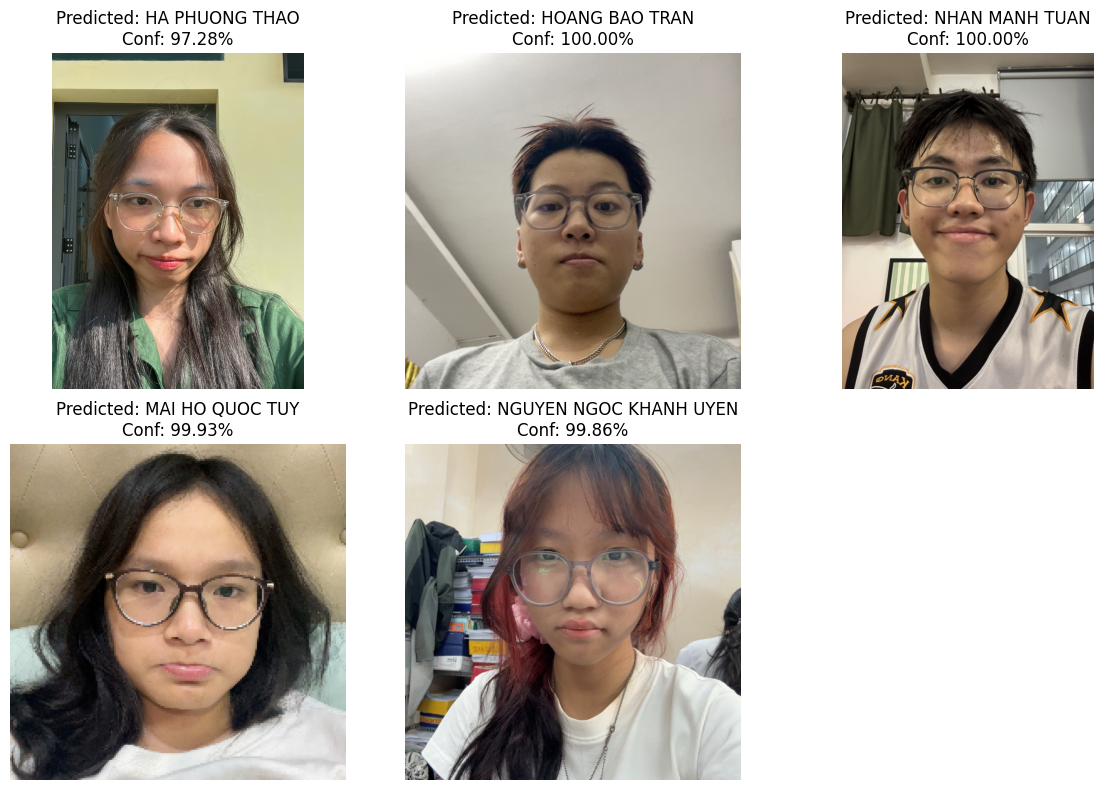

Image testing complete.


In [9]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/content/face_id_final_model.keras')

image_files = [
    '/content/thao.jpg',
    '/content/tran.PNG',
    '/content/tuan.jpg',
    '/content/tuy.jpg',
    '/content/uyen.jpg'
]

print(f"Testing model with {len(image_files)} images...")

num_images = len(image_files)
num_cols = 3
num_rows = (num_images + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 4, num_rows * 4))
for i, image_path in enumerate(image_files):
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}. Skipping.")
        continue

    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}. Skipping.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB);
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0);
    predictions = model.predict(img_input)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_class_name}\nConf: {confidence:.2f}%")
    plt.axis('off')

plt.tight_layout()
plt.show()
print("Image testing complete.")